 # iValue_TW — 無形資本調整價值因子（intangible-adjusted B/M）

| 項目 | 內容 |
|------|------|
| **策略邏輯** | **Step1 資本化**：把被費用化的 R&D（δ=0.15）與 30% SG&A（δ=0.20）用永續盤存還原成無形資本、加回淨值 → iBook = Book + 知識資本 G + 組織資本 O；**Step2 因子**：iB/M = iBook ÷ 市價（與傳統 B/M 同尺度，越高＝相對真實資產越便宜）；**Step3 投組**：流動母體（市值≥50億）選 iB/M 前 20 檔、反波動率加權、每年 6 月再平衡。｜算法細節見 §4-D。 |
| **架構** | 財報選股架構 |
| **調倉頻率** | 年度（每年 6 月第一個交易日；持有 12 個月） |
| **股票池** | TSE/OTC 上市櫃普通股 |
| **Alpha 來源** | Arnott, Harvey, Kalesnik & Linnainmaa (2021)；Lev & Srivastava (2020)；資本化方法 Peters & Taylor (2017) |
| **資料來源** | TEJ（`get_universe`、TWN/APRCD1 via TejToolAPI、**TWN/AINVFINB** 年度財報＋公告日(PIT)、IR0001 報酬指數）｜2026-08-31 起由 TWN/AIM1A + TWN/AIM1AA 換來，因 TQuant Lab 授權不含 AIM1A，對照見 §1 |

> **核心 Alpha**：R&D 與 30% SG&A 被會計費用化、不列資產 → 傳統 B/M 誤把 R&D 密集公司分類為「貴」。把無形資本加回淨值得 iB/M，更準確分辨價值/成長。
> **因子計算方式？**  §4-D 有逐步公式與數值例。
> **前視偏差防護（PIT）**：財報 as-of 採 **TWN/AINVFINB.key3 首次公告日**（point-in-time，非規則式右移）。`key3` 屬 primary key，同一會計年度會有多個公告日版本（隔年年報的比較期會回填重編值），本版一律取首次公告版本，因此連「事後重編」這層 look-ahead 也一併排除——舊版透過 AIM1A 只能取得重編後終值，樣本中 7.0% 的年度研發費事後被重編過。永續盤存自 2005 起 burn-in。
>
> **金融業排除**：AINVFINB 將金融三業科目置於不同欄位（證券業 `a3300`/`a3356` 全為 NaN），且本因子對金融業無定義（Peters-Taylor 原論文亦排除），故以 `ind_c` 明確剔除。舊版 AIM1A 的 `3300` 對券商有值，曾使 6016 康和證在 2015–2020 每期入選。

---
## 0｜環境設定

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import tejapi
import TejToolAPI
import matplotlib.pyplot as plt
from logbook import Logger

plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

TEJAPI_KEY  = os.environ.get('TEJAPI_KEY', 'OtVW2EHGLxDzifJ5ywGfTMD6qRh2mm')
TEJAPI_BASE = os.environ.get('TEJAPI_BASE', 'http://tejapi.tejwin.com')
if not TEJAPI_KEY:
    raise RuntimeError('找不到 TEJAPI_KEY，請先設定環境變數 TEJAPI_KEY 再執行本 notebook。')
os.environ['TEJAPI_KEY']  = TEJAPI_KEY
os.environ['TEJAPI_BASE'] = TEJAPI_BASE
tejapi.ApiConfig.api_key  = TEJAPI_KEY
tejapi.ApiConfig.api_base = TEJAPI_BASE
tejapi.ApiConfig.ignoretz = True

log = Logger('iValue_TW')
print('環境設定完成')


環境設定完成


In [2]:
# ── 回測參數 ──────────────────────────────────────────────────
START_DATE   = '2015-06-01'   # 回測開始（首次年度再平衡）
END_DATE     = '2026-05-31'   # 回測結束
PRICE_START  = '2014-01-01'   # 日行情下載起點
FIN_START    = '2005-01-01'   # 財報下載起點（永續盤存 burn-in）
FIN_END      = END_DATE       # 財報下載終點；跟著 END_DATE 走
# ⚠ 原本 3-C 把財報的 lte 硬編碼在 '2024-12-31'，與 END_DATE 脫節：
#   回測跑到 2026-05-31，但 2026-05-31 的訊號只拿得到 FY2024 年報
#   （FY2025 年報 2026-03 才公告，被硬編碼擋掉）。改由 FIN_END 統一。

DELTA_RD     = 0.15           # R&D 折舊率（知識資本）
DELTA_SGA    = 0.20           # SG&A 折舊率（組織資本）
SGA_CAP      = 0.30           # SG&A 資本化比例（Peters-Taylor）
G0_GROWTH    = 0.10           # 永續盤存初始存量穩態成長假設
N_STOCKS     = 20             # 最終選股數量
MV_MIN       = 5_000_000_000  # 流動母體市值門檻（50 億元）
WEIGHTING    = 'invvol'       # 加權方式：'invvol'
VOL_LOOKBACK = 12             # 反波動率的尾隨月報酬波動視窗（月）
REBAL_MONTH  = 6              # 年度再平衡月份
CAPITAL_BASE = 100_000_000    # 初始資金（新台幣）

print(f'回測期間: {START_DATE} ~ {END_DATE}（年度調倉，持有12個月）')
print(f'規格: SGA資本化 {SGA_CAP:.0%}、δ_RD={DELTA_RD} | 選股 {N_STOCKS} 檔、市值≥{MV_MIN/1e8:.0f}億、加權={WEIGHTING}')

回測期間: 2015-06-01 ~ 2026-05-31（年度調倉，持有12個月）
規格: SGA資本化 30%、δ_RD=0.15 | 選股 20 檔、市值≥50億、加權=invvol


---
## 1｜Data Contract 與資料驗證

| 研究變數 | TEJ 資料表 | 請求欄位 | 回傳欄名 | 頻率 | 備註 |
|---------|-----------|---------|---------|------|------|
| 個股還原報酬 | TWN/APRCD1 (TejToolAPI) | `roi` | `ROI` | 日→月底 | %，已還原(含息) |
| 個股市值 | TWN/APRCD1 (TejToolAPI) | `mktcap` | `Market_Cap_Dollars` | 日→月底 | 流動性門檻(≥50億) |
| 證券種類 | TWN/APISTKATTR (TejToolAPI) | `stktp_e` | `Security_Type_English` | 日 | 排除 ETF/特別股 |
| 全額交割/注意/處置 | TWN/APISTKATTR (TejToolAPI) | `full_fg`,`atten_fg`,`disp_fg` | `*_Stock_Fg` | 日 | 流動性濾網 |
| 研究發展費 | **TWN/AINVFINB** | `a3356` | 研究發展費（年度累計） | 年 | 知識資本 G 的投入。與舊 `AIM1A.3356` 逐筆比對 **99.79% 相同** |
| 營業費用 | **TWN/AINVFINB** | `a3300` | 營業費用 | 年 | SGA 基數 = a3300−a3356。與舊 `3300` **99.54% 相同** |
| 母公司股東權益 | **TWN/AINVFINB** | `a200e` | 帳面淨值 Book | 年 | iBook 基底。與舊 `200E` **100% 逐筆相同（最大差 0）** |
| 產業別 | **TWN/AINVFINB** | `ind_c` | 一般／銀行／金控／證券／保險 | 年 | 用於剔除金融業（科目定義不同、因子無定義）|
| 年末 P/B（重建）| TWN/APRCD1 + AINVFINB | `mktcap` ÷ `a200e` | 股價淨值比 | 年 | AINVFINB 無 P/B 欄位；`R537` 定義即市值÷母公司權益，重建後 **r = 1.00000**、相對誤差中位 0.156% |
| **財報公告日(PIT)** | **TWN/AINVFINB** | `key3` | 公告日 | 年 | **point-in-time as-of**。屬 primary key，取首次公告版本；與舊 `AIM1AA.a0003` **87.8% 同日** |
| 基準指數 | zipline `tquant` bundle | `IR0001` | 發行量加權報酬指數(含息) | 日 | Zipline 回測基準 |

> **前視偏差防護（PIT）**：財報 as-of 採 **TWN/AINVFINB.key3 首次公告日**（非規則式右移）；訊號日僅使用「當下已公告」財報。全母體 30,556 筆年報中公告日無一缺漏（`key3` 屬 primary key，不像 `AIM1AA.a0003` 會有空值），公告月份 **75.5% 落在 3 月**，訊號日 5/31 有充裕緩衝。
> **為什麼不用 TejToolAPI**：`TejToolAPI.get_history_data` 的授權欄位只有研發費用「率」（`r203`），沒有金額。舊版因此改抓長格式 `TWN/AIM1A` 直取 `acc_code`——但 **TQuant Lab 的授權不含 AIM1A**。`TWN/AINVFINB`（財務資料_會計師簽證財務資料，118 科目，寬表，2005 年起）四個科目全備且多了公告日，是正確的替代表。查詢加 `no='A'`（累計）+ `sem='4'`（年報）在伺服器端過濾，鍵值與客端過濾完全相同、流量少 75%。

---
## 2｜股票池

In [3]:
from zipline.sources.TEJ_Api_Data import get_universe

# TSE/OTC 上市櫃普通股
pool = get_universe(
    start=pd.Timestamp(PRICE_START, tz='UTC'),
    end=pd.Timestamp(END_DATE,     tz='UTC'),
    mkt_bd_e=['TSE', 'OTC'],
    stktp_e='Common Stock',
)
print(f'股票池（歷史曾出現）: {len(pool)} 檔')

Currently used TEJ API key call quota 46/100000 (0.05%)
Currently used TEJ API key data quota 4859869/10000000 (48.6%)
股票池（歷史曾出現）: 1948 檔


---
## 3｜資料下載

In [4]:
# ── 3-A  日行情（月底報酬率 + 市值）───────────────────────────
price_raw = TejToolAPI.get_history_data(
    ticker=pool, columns=['roi', 'mktcap'],
    start=PRICE_START, end=END_DATE, transfer_to_chinese=False)
print('[price_raw] columns:', price_raw.columns.tolist(), '| shape:', price_raw.shape)
price_raw.head(3)

Currently used TEJ API key call quota 166/100000 (0.17%)
Currently used TEJ API key data quota 19942545/10000000 (199.43%)
[price_raw] columns: ['coid', 'mdate', 'ROI', 'Market_Cap_Dollars'] | shape: (4859850, 4)


,coid,mdate,ROI,Market_Cap_Dollars
0,1101,2014-01-02,-1.8378,1.676248e+11
1,1101,2014-01-03,-1.8722,1.644864e+11
2,1101,2014-01-06,-2.1324,1.609789e+11


In [5]:
# ── 3-B  證券種類 + 流動性旗標 ────────────────────────────────
attr_raw = TejToolAPI.get_history_data(
    ticker=pool, columns=['stktp_e', 'full_fg', 'atten_fg', 'disp_fg'],
    start=PRICE_START, end=END_DATE, transfer_to_chinese=False)
print('[attr_raw] columns:', attr_raw.columns.tolist(), '| shape:', attr_raw.shape)
attr_raw.head(3)

Currently used TEJ API key call quota 286/100000 (0.29%)
Currently used TEJ API key data quota 35025221/10000000 (350.25%)
[attr_raw] columns: ['coid', 'mdate', 'Security_Type_English', 'Attention_Stock_Fg', 'Disposition_Stock_Fg', 'Full_Delivery_Stock_Fg'] | shape: (4859850, 6)


,coid,mdate,Security_Type_English,Attention_Stock_Fg,Disposition_Stock_Fg,Full_Delivery_Stock_Fg
0,1101,2014-01-02,Common Stock,,,
1,1101,2014-01-03,Common Stock,,,
2,1101,2014-01-06,Common Stock,,,


In [6]:
# ── 3-C  年度財報（研發/營業費用/母公司淨值）+ 公告日 ─────────────
# ⚠ 資料源已從 TWN/AIM1A 換成 TWN/AINVFINB：TQuant Lab 的授權未包含 AIM1A
#   （長格式「IFRS以合併為主簡表」）。AINVFINB =「財務資料_會計師簽證財務資料
#   (118個科目)」是寬表，本策略需要的科目全都在裡面，而且多了公告日：
#       a3356 研究發展費        ← 取代 acc_code 3356
#       a3300 營業費用          ← 取代 acc_code 3300
#       a200e 母公司股東權益合計 ← 取代 acc_code 200E
#       key3  公告日            ← 取代 TWN/AIM1AA.a0003（原 3-D 整段因此刪除）
#   實測 139 檔 × 2005~2022：a200e 與 200E 100% 逐筆相同，a3356 99.79%、
#   a3300 99.54% 相同（差異來自重編版本，見下）。R537 季底P/B 無對應欄位，
#   改由「年末市值 ÷ 母公司權益」重建（見 4-C），與 R537 相關係數 1.00000。
#
# ▶ PIT 上的改善：key3 是 primary key 的一部分，同一個會計期間會有多個公告日
#   版本——隔年年報的「比較期」會把重編後的數字回填成新的一列。AIM1A 只給重編
#   後的終值（無公告日，得再併 AIM1AA），等於在訊號日用到了當時還不存在的數字。
#   這裡一律取「首次公告版本」（key3 最小），avail_date 就是該次公告日，
#   完全消除這層 look-ahead。實測樣本有 7.0% 的年度研發費事後被重編過。
#
# no='A' 累計值、sem='4' 年報：兩個都在伺服器端過濾，等價於「抓全部季度再客端
# 濾 12 月」但流量少 75%（實測 592 列 → 149 列，鍵值完全相同）。
FINB_COLS = ['coid', 'mdate', 'key3', 'ind_c', 'a3356', 'a3300', 'a200e']
parts = []
for i in range(0, len(pool), 60):
    parts.append(tejapi.get('TWN/AINVFINB', coid=pool[i:i+60], no='A', sem='4',
        mdate={'gte': FIN_START, 'lte': FIN_END},
        opts={'columns': FINB_COLS}, paginate=True))
finb = pd.concat(parts, ignore_index=True)
finb['coid']  = finb['coid'].astype(str)
finb['mdate'] = pd.to_datetime(finb['mdate'])
# key3 是 char(24) 字串，格式不一致（2013 年起帶毫秒）→ 必須 format='mixed'
finb['key3']  = pd.to_datetime(finb['key3'], format='mixed')
finb = finb[finb['mdate'].dt.month == 12].copy()          # 保險：sem='4' 已保證 12 月
finb['year']  = finb['mdate'].dt.year

# ▶ 金融業必須剔除：AINVFINB 把金融三業的科目放在不同欄位，證券業的 a3300/a3356
#   全為 NaN（改記於 a310c 收益合計_證券、a3600 支出及費用合計_證券），金控業
#   a3356 全為 NaN。若不剔除，這些公司會被當成「研發＋組織資本皆為 0」而以純
#   B/M 混入排序。本因子是把研發/管銷費用資本化成無形資產，對金融業本無定義
#   （Peters-Taylor 原始論文亦排除金融業），因此直接以 ind_c 剔除。
#   註：舊版 AIM1A 的 3300 對券商有值，所以券商曾被選進投組——那是錯誤覆蓋。
_n_fin = finb['ind_c'].isin(['銀行業', '金控業', '證券業', '保險業'])
print(f'[finb] 剔除金融業 {int(_n_fin.sum())} 筆（{sorted(finb.loc[_n_fin, "ind_c"].unique())}）')
finb = finb[~_n_fin].copy()

# 每個 (coid, year) 取首次公告版本 → 一列，avail_date = 首次公告日
fin_wide = (finb.sort_values('key3').groupby(['coid', 'year'], as_index=False).first()
                .rename(columns={'a3356': 'rd_raw', 'a3300': 'opex_raw',
                                 'a200e': 'book_raw', 'key3': 'avail_date'}))
fin_wide = fin_wide[['coid', 'year', 'avail_date', 'rd_raw', 'opex_raw', 'book_raw']]
print('[fin_wide] columns:', fin_wide.columns.tolist(), '| shape:', fin_wide.shape)
print('[fin_wide] 公告月份分布:',
      fin_wide['avail_date'].dt.month.value_counts().sort_index().to_dict())
fin_wide.head(3)


[finb] 剔除金融業 1441 筆（['保險業', '證券業', '金控業', '銀行業']）
[fin_wide] columns: ['coid', 'year', 'avail_date', 'rd_raw', 'opex_raw', 'book_raw'] | shape: (30556, 6)
[fin_wide] 公告月份分布: {1: 91, 2: 2533, 3: 23084, 4: 4757, 5: 57, 6: 20, 7: 7, 9: 3, 12: 4}


,coid,year,avail_date,rd_raw,opex_raw,book_raw
0,1101,2005,2006-03-31,33568.0,2030687.0,56420387.0
1,1101,2006,2007-04-24,47849.0,2507284.0,67042840.0
2,1101,2007,2008-04-28,42990.0,2498024.0,82826916.0


---
## 4｜資料前處理

In [7]:
# ── 4-A  取月底日行情 ─────────────────────────────────────────
price_raw['coid']  = price_raw['coid'].astype(str)
price_raw['mdate'] = pd.to_datetime(price_raw['mdate'])
price_monthly = (price_raw.sort_values('mdate')
    .groupby(['coid', pd.Grouper(key='mdate', freq='ME')]).last().reset_index())
print('月底行情筆數:', price_monthly.shape)
price_monthly.head(3)

月底行情筆數: (239816, 4)


,coid,mdate,ROI,Market_Cap_Dollars
0,1101,2014-01-31,-2.3153,1.635634e+11
1,1101,2014-02-28,1.5773,1.783321e+11
2,1101,2014-03-31,-0.4237,1.735323e+11


In [8]:
# ── 4-B  流動性濾網（普通股 + 非全額交割/注意/處置）月底值 ───
# ⚠ TEJ 這三個旗標欄位的值域是字串 'Y' / ''（不是 0/1）。
#   舊版寫成 `!= 1`，拿整數去比字串永遠為 True → 三個旗標從未生效，
#   這一格實際上只做了「普通股」過濾。已改為字串比對，並印出各條件剔除筆數自我驗證。
attr_raw['coid']  = attr_raw['coid'].astype(str)
attr_raw['mdate'] = pd.to_datetime(attr_raw['mdate'])
attr_monthly = (attr_raw.sort_values('mdate')
    .groupby(['coid', pd.Grouper(key='mdate', freq='ME')]).last().reset_index())

def _is_flagged(col):
    """旗標成立＝'Y'（容錯大小寫與空白）；欄位不存在時一律視為未成立。"""
    if col not in attr_monthly.columns:
        return pd.Series(False, index=attr_monthly.index)
    return attr_monthly[col].astype(str).str.strip().str.upper().isin(['Y', '1', 'TRUE'])

_n0 = len(attr_monthly)
is_common = (attr_monthly['Security_Type_English'].astype(str).str.strip() == 'Common Stock'
             if 'Security_Type_English' in attr_monthly.columns
             else pd.Series(True, index=attr_monthly.index))
flagged = (_is_flagged('Full_Delivery_Stock_Fg')
           | _is_flagged('Attention_Stock_Fg')
           | _is_flagged('Disposition_Stock_Fg'))
attr_monthly = attr_monthly[is_common & ~flagged].copy()
print(f'月底可交易筆數: {_n0} → {len(attr_monthly)}　'
      f'(非普通股剔除 {int((~is_common).sum())}、三旗標任一成立剔除 {int((is_common & flagged).sum())})')

月底可交易筆數: 239816 → 232864　(非普通股剔除 0、三旗標任一成立剔除 6952)


In [9]:
# ── 4-C  年度財報 as-of 對齊（PIT：財報公告日）──────────────────
# avail_date = TWN/AINVFINB.key3 首次公告日（point-in-time）；無公告日者剔除
fin = fin_wide.rename(columns={'book_raw': 'book', 'opex_raw': 'opex', 'rd_raw': 'rd'}).copy()
for c in ('rd', 'opex', 'book'):
    fin[c] = pd.to_numeric(fin[c], errors='coerce')
n_before = len(fin); fin = fin.dropna(subset=['avail_date'])

# ▶ 重建 R537（季底P/B）：AINVFINB 沒有 P/B 欄位，而 R537 的定義就是
#   「市值 ÷ 母公司股東權益」——實測 1,922 筆 r=1.00000、相對誤差中位 0.156%。
#   市值取會計年度最後一個交易日（＝R537 的「季底」，也就是 4-D 說明中
#   「分母價格＝t-1 年 12 月底」的 FF 慣例，時點語意與原版完全相同）。
#   單位：Market_Cap_Dollars 是「元」、book 是「千元」，故除以 1000 對齊。
_px = price_raw[['coid', 'mdate', 'Market_Cap_Dollars']].copy()
_px['year'] = _px['mdate'].dt.year
mv_ye = (_px.dropna(subset=['Market_Cap_Dollars']).sort_values('mdate')
            .groupby(['coid', 'year'], as_index=False).last()
            .rename(columns={'Market_Cap_Dollars': 'mktcap_ye'})[['coid', 'year', 'mktcap_ye']])
fin = fin.merge(mv_ye, on=['coid', 'year'], how='left')
fin['pb'] = (fin['mktcap_ye'] / 1000.0) / fin['book']

fin['rd']  = fin['rd'].fillna(0.0).clip(lower=0)
fin['sga'] = ((fin['opex'].fillna(0.0) - fin['rd']).clip(lower=0)) * SGA_CAP  # 30% of (營業費用−研發)
print(f'財報 as-of=PIT 公告日；{n_before}→{len(fin)} 筆（剔除無公告日）'
      f'｜可算 P/B {int(fin["pb"].notna().sum())} 筆')
fin[['coid', 'year', 'avail_date', 'rd', 'opex', 'book', 'pb']].head(3)


財報 as-of=PIT 公告日；30556→30556 筆（剔除無公告日）｜可算 P/B 18888 筆


,coid,year,avail_date,rd,opex,book,pb
0,1101,2005,2006-03-31,33568.0,2030687.0,56420387.0,NaN
1,1101,2006,2007-04-24,47849.0,2507284.0,67042840.0,NaN
2,1101,2007,2008-04-28,42990.0,2498024.0,82826916.0,NaN


### 4-D 因子怎麼算

**介紹**：把被會計「費用化」的研發與部分 SG&A，用**永續盤存法**還原成無形資本，加回帳面淨值，再算 B/M。

**為什麼要這樣做**：R&D、品牌／組織投資在會計上是「當期費用」、不進資產負債表 → 帳面淨值 `book` 被系統性低估 → 傳統 B/M 把研發密集的好公司誤判成「太貴的成長股」而排除在價值組外。iB/M 就是把這些看不見的無形資產加回來，還原「真實的便宜度」。

---

#### Step A — 把「費用流量」滾成「資本存量」（永續盤存）

財報上的研發費、SG&A 是**流量**（今年花多少）；我們要的是**存量**（歷年投入、扣掉逐年老化，累積到今天還剩多少）。用標準遞迴：

$$K_t = (1-\delta)\,K_{t-1} + I_t$$

- $K_{t-1}$：去年底的資本存量；$(1-\delta)$：**存活率**（知識/組織每年老化掉 $\delta$）；$I_t$：今年新投入。
- **期初種子**（進樣本前早就累積的資本）用穩態假設 $K_0 = I_1/(g_0+\delta)$。

**逐年數值例**（研發持平在 10、$\delta=0.15$）：

| 年 | 投入 $I$ | 計算 | 存量 $K$ |
|---|---|---|---|
| 種子 $K_0$ | 10 | $10/(0.10+0.15)$ | 40.0 |
| 1 | 10 | $0.85\times40.0+10$ | 44.0 |
| 2 | 10 | $0.85\times44.0+10$ | 47.4 |
| … | 10 | … | → 66.7（穩態 $=I/\delta$）|

這個遞迴跑**兩次**，得到兩塊無形資本：**G＝知識資本**（投入＝研發費，$\delta_{RD}=0.15$）、**O＝組織資本**（投入＝ SG&A×30%，$\delta_{SGA}=0.20$）。

> **遞迴的前提**：程式對「相鄰兩列」做遞推，所以必須確認相鄰列真的是相鄰年度。少數公司財報年度有缺口（例如缺 2009），若不處理會少折舊一次、高估存量。下一格已先補成連續年度網格（缺年投入以 0 計）再遞推。

> **種子的影響有多大，取決於公司有多少年歷史**。上市較晚的公司，$K_0$ 幾乎就是它的無形資本估計值本身，不是累積出來的。這件事在 **4-E** 有量化：2015 年訊號時約 13% 的母體歷史不到 5 年（但實際選中的 top-20 中位歷史 9 年以上）。

---

#### Step B — 組出調整後淨值與 iB/M

$$\text{ibook} = \text{book} + G + O$$

$$\text{ibm} = \underbrace{\frac{1}{pb}}_{=\,\text{book}/\text{price}} \times \frac{\text{ibook}}{\text{book}} = \frac{\text{ibook}}{\text{price}}$$

`book` 在分子分母**約掉**了——所以 **iB/M 的真正意義就是「含無形資產的淨值 ÷ 市價」**，跟傳統 B/M 完全同一把尺（都是「便宜度」），只是分子換成了看得見無形資產的淨值。**iB/M 越高＝相對它的真實資產越便宜**。（用 `1/pb` 繞道，是為了免抓股數/股價、免除權息還原就把 price 帶進來。）

---

#### ⚠ 分母的「價格」是哪一天？——這是本因子最容易被誤解的地方

分母的價格由「會計年度最後一個交易日的市值」帶入（4-C 以 `mktcap ÷ a200e` 重建 P/B，取代原本 `TWN/AIM1A` 的季頻 `R537` 只留 12 月的做法）。**時點語意與原版完全相同**，因此：

| 項目 | 時點 |
|---|---|
| 分子 `ibook`（含無形淨值） | 會計年度 $t-1$ 年底 |
| 分母 `price`（由 `1/pb` 帶入，pb = 年末市值÷母公司權益） | **$t-1$ 年 12 月最後一個交易日** |
| 訊號日（排序、選股） | $t$ 年 5/31 |
| 實際進場 | $t$ 年 6 月首個交易日 |

**分母的價格比進場價早約 6 個月**，這是刻意的：它就是 Fama-French 的標準做法（用 $t-1$ 年 12 月的市值 + 該會計年度的淨值，隔年 6 月成形），好處是分子分母同時點、不會把年初到 5 月的價格動能混進價值訊號裡。

代價是訊號在進場時已經「舊了半年」。**本交付版採 FF 慣例（12 月）**，此處明列以免誤讀——讀者若把它當成「當下估值」而改成每月重算，因子會逐步變質為短期反轉，那是完全不同的策略。

> 事後檢驗（見 4-E）：把分母換成 1、2、3、4、5 月的價格，**CAGR 與 Sharpe 全部比 12 月差**。較新的價格會把「1–5 月剛暴跌所以看起來便宜」的股票排進來，而那些股票之後並未反彈。此檢驗是先依文獻定案、事後才驗證，非掃參數挑選。

---

#### 參數（四個全部固定用學術值、**不做優化**）

| 參數 | 值 | 意義 |
|---|---|---|
| `DELTA_RD` | 0.15 | 研發知識年折舊率（Peters-Taylor 標準值）|
| `DELTA_SGA` | 0.20 | 組織資本年折舊率（比研發老化快）|
| `SGA_CAP` | 0.30 | SG&A 中屬「投資性質」的比率（品牌/通路/人力）|
| `G0_GROWTH` | 0.10 | 期前投入成長率（僅影響 burn-in 期的種子）|

> **誠實提醒**：$\delta$ 越小 → 資本存量越大 → 對研發密集股的 tilt 越強。因此報酬對 $\delta_{RD}$ 有敏感度。**因子四參數刻意固定不優化**，避免 in-sample 過擬合；優化只發生在投組層（選股數 N、加權方式）。敏感度的實際幅度見 **4-E**：δ 在合理區間內名單保留 90–93%，拿掉無形調整才會掉到 46%。

In [10]:
# ── 4-D  永續盤存 → 無形調整淨值 iBook → iB/M 因子 ─────────────
# ▶ 直覺與公式見上方 markdown「4-D 因子怎麼算」；以下為對應實作。
def perpetual(vals, delta, g0=G0_GROWTH):
    stock = np.full(len(vals), np.nan); prev = None
    for i, x in enumerate(vals):
        k0 = (x / (g0 + delta) if x > 0 else 0.0)              # 穩態初值（僅第一年用到）
        k = (1 - delta) * (k0 if prev is None else prev) + x   # K_t=(1-δ)·K_{t-1}+I_t
        stock[i] = k; prev = k
    return stock

# ── Step A：對每家公司按年序跑永續盤存，跑兩次得兩塊無形資本 ──
# 遞迴假設「相鄰列＝相鄰年」。少數公司年度有缺口，直接遞推會少折舊 → 先補成
# 連續年度網格（缺年投入以 0 計）再遞推，最後只取回原本存在的年度。
fin = fin.sort_values(['coid', 'year']).reset_index(drop=True)

def _perpetual_on_grid(col, delta):
    out = pd.Series(index=fin.index, dtype=float)
    for _, g in fin.groupby('coid', sort=False):
        yrs = np.arange(int(g['year'].min()), int(g['year'].max()) + 1)
        flow = g.set_index('year')[col].reindex(yrs).fillna(0.0).values
        k = pd.Series(perpetual(flow, delta), index=yrs)
        out.loc[g.index] = k.reindex(g['year']).values
    return out

_gap_firms = int((fin.groupby('coid')['year'].apply(lambda s: (s.diff().dropna() != 1).any())).sum())
fin['G'] = _perpetual_on_grid('rd',  DELTA_RD)    # 知識資本
fin['O'] = _perpetual_on_grid('sga', DELTA_SGA)   # 組織資本
print(f'永續盤存完成；年度有缺口需補格的公司 {_gap_firms} 家')

# ── Step B：ibook=book+G+O；ibm=(1/pb)·(ibook/book)=ibook/price（book 約掉，與 B/M 同尺度）──
fac = fin[(fin['book'] > 0) & (fin['pb'] > 0)].copy()          # 淨值/PB 為負者剔除
fac['bm']  = 1.0 / fac['pb']                                   # 純 B/M
fac['ibm'] = fac['bm'] * ((fac['book'] + fac['G'] + fac['O']) / fac['book'])   # iB/M
fac['intang_ratio'] = (fac['G'] + fac['O']) / fac['book']
fac = fac[['coid', 'year', 'avail_date', 'bm', 'ibm', 'intang_ratio']]
print(f'iB/M 因子筆數: {fac.shape} | 無形/淨值 中位 {fac["intang_ratio"].median():.2f} 均 {fac["intang_ratio"].mean():.2f}')
fac[fac.year == 2023].nlargest(6, 'intang_ratio').round(2)

永續盤存完成；年度有缺口需補格的公司 3 家
iB/M 因子筆數: (18882, 6) | 無形/淨值 中位 0.39 均 0.67


,coid,year,avail_date,bm,ibm,intang_ratio
27905,8101,2023,2024-03-29 15:10:08.253,0.31,12.44,38.92
11533,3064,2023,2024-03-15 14:04:19.975,0.21,2.72,11.82
5906,2321,2023,2024-03-12 17:22:11.283,0.96,6.95,6.26
21629,5903,2023,2024-03-12 18:56:04.506,0.18,1.13,5.36
10336,2926,2023,2024-02-23 18:54:03.124,0.18,1.14,5.35
14970,3555,2023,2024-02-28 11:54:01.457,0.20,1.11,4.63


---

## 4-E　因子驗證結果

因子層做過的九項查核與結論如下。**驗證程式不放在交付本，另存於 `paper04/_factor_validation.py`**，
需要重新查核或改了因子定義時執行該腳本即可重現本表。

> ### ⚠ 本表為 **TWN/AIM1A 時期** 的驗證結果，尚未在新資料源下重跑
>
> 2026-08-31 資料源改為 `TWN/AINVFINB`，並一併做了兩項改變選股結果的決策
> （剔除金融業、PIT 取首次公告版本）。這兩項使 Top-20 與原版重疊由 18–20/20 降至 13–17/20，
> 因此下表凡涉及「名單差異」「發布日」「burn-in 母體」的列都**必須重跑才算成立**：
>
> | 下表項目 | 狀態 |
> |---|---|
> | 前視偏差、PIT vs 保守 5/31、財報發布落後 | **待重驗** —— 公告日來源已由 `AIM1AA.a0003` 改為 `AINVFINB.key3` |
> | Burn-in 深度、極端值、相對純 B/M 增量、參數敏感度 | **待重驗** —— 母體已剔除金融業（全母體 1,441 筆年報） |
> | 價格時點、交易旗標濾網 | 不受影響（機制未變；價格時點語意相同） |
>
> `_factor_validation.py` 本身仍指向舊表，**要先改資料源再執行**。
> 本次換源已完成的驗證是「欄位等價性」（見 §1 表格）與「全母體可跑通」
> （1,956 檔、30,556 筆年報、12 期每期滿 20 檔），不等於因子層九項查核。

| 查核項目 | 結果 |
|---|---|
| **前視偏差** | 財報發布日早於會計年度年底者 **0%**——無前視 |
| **PIT vs 保守 5/31** | 最終選股名單**逐年零差異**。PIT 的價值在於可證明沒有前視，而非改變名單 |
| **財報發布落後** | 中位 2.4–3.0 個月；每年 1.6–11.4% 的公司落後逾 12 個月（晚報的問題公司，多半通不過市值門檻）|
| **價格時點** | 分母採 12 月（FF 慣例，先定後驗） |
| **Burn-in 深度** | 母體 2.4–13% 歷史不足 5 年（前段較多）；但實際選中的 **top-20 中位歷史 9 年以上**，每年至多 2 檔不足 5 年 |
| **極端值** | 無形/淨值最大逾 300 倍，但市值 ≥50 億門檻已將長尾擋在門外——top-20 每年至多 1 檔超過 3 倍，**不需 winsorize** |
| **相對純 B/M 的增量** | 流動母體內秩相關 0.91–0.95，但 **top-20 名單平均只重疊 9.2/20** → 無形調整換掉約一半投組 |
| **參數敏感度** | δ_RD、δ_SGA、SGA_CAP 在合理區間內移動，名單保留 90–93%；完全不做無形調整只剩 46%。**決定性的是「做不做」而非取值** |
| **交易旗標濾網** | 注意/處置/全額交割濾網十年只改變 12 個持股欄位，績效差異 ≤ 0.1pp |

### 已知限制

1. **價格時點落後 6 個月**是設計選擇（Fama-French 慣例，先選定再驗證），不是掃參數挑出來的。
2. **Burn-in 不均**使回測前段的母體排序品質弱於後段；top-20 受影響有限，但 IS/OOS 比較會受此汙染。
3. ~~`TWN/AIM1AA.a0003` 在 2007 年前為回填值~~ → 已不適用（公告日改用 `AINVFINB.key3`）。**新的對應限制**：`key3` 在 2013 年之前每個會計期間只有單一版本、2013 年起才出現「首次公告 + 隔年重編」兩列，因此「取首次公告版本」這個 PIT 保護**在 2013 年前形同無效**（只有一個版本可取，且無法判斷它是原始值或重編值）。本回測期間（2015 起）的訊號不受影響，但 burn-in 段（2005–2012）的研發/營業費用可能已含事後重編，**樣本往前延伸必須先處理**。
4. 秩相關 0.91+ 代表 iB/M 與 B/M 在排序上高度一致，增量來自尾端重排。**若 B/M 本身失效，iB/M 大機率一起失效。**
5. 以上皆為**因子層**驗證。投組層參數（選股數 N、市值門檻、加權方式）是在全期資料上選定的，因此後半期並非獨立樣本外。
6. **金融業排除是新增的母體限制**（本次換源一併決定）。理由是 AINVFINB 的金融三業科目定義不同且本因子對其無定義，但這確實縮小了母體：舊版曾把券商（6016）選進投組。若要與舊結果逐期對照，需把此開關關掉重跑。
7. **滑價假設為零**（`NoSlippage`），僅計手續費 3.5 折與證交稅 0.3%。持股為 20 檔中小型價值股、年換手約 45%（12 期平均留存 11/20），實際市場衝擊成本不會是零。

---
## 5｜`compute_stock`：每期選股邏輯

In [11]:
def get_latest_factor(as_of_date, fac_df, col='ibm'):
    '''取 as_of 當下最新一筆已可用（avail_date<=as_of）的因子值。'''
    elig = fac_df[fac_df['avail_date'] <= as_of_date]
    return (elig.sort_values('avail_date').groupby('coid').last().reset_index()[['coid', col]])

def compute_stock(signal_date, price_df, attr_df, fac_df,
                  n_stocks=N_STOCKS, mv_min=MV_MIN, col='ibm'):
    '''流動母體(市值≥mv_min、可交易) 內選 iB/M 前 n_stocks 檔。'''
    attr_t = attr_df[attr_df['mdate'] == signal_date][['coid']].copy()
    if attr_t.empty:
        return []
    mv_t = price_df[price_df['mdate'] == signal_date][['coid', 'Market_Cap_Dollars']]
    liquid = mv_t[mv_t['Market_Cap_Dollars'] >= mv_min].merge(attr_t, on='coid')   # 可交易且大於門檻
    sig = get_latest_factor(signal_date, fac_df, col)
    cand = liquid.merge(sig, on='coid', how='inner').dropna(subset=[col])
    if len(cand) < 20:
        return []
    return cand.nlargest(n_stocks, col)['coid'].tolist()

print('compute_stock 定義完成（流動母體 iB/M top-N）')

compute_stock 定義完成（流動母體 iB/M top-N）


---
## 6｜產生年度選股名單（每年 5 月底訊號）

In [12]:
# 年度策略：每年 5 月底為訊號日，次月(6月)首交易日換倉、持有 12 個月
signal_dates = pd.date_range(start='2015-05-31', end=END_DATE, freq='ME')
signal_dates = [d for d in signal_dates if d.month == 5]

stock_list_by_date = {}
for sig in signal_dates:
    stock_list_by_date[sig] = compute_stock(sig, price_monthly, attr_monthly, fac)

counts = pd.Series({d: len(v) for d, v in stock_list_by_date.items()})
print(f'年度數: {len(counts)} | 每期平均選股: {counts.mean():.0f} 檔')
last = max(stock_list_by_date); print(f'最後一期 ({last.date()}) {len(stock_list_by_date[last])} 檔:')
print(stock_list_by_date[last])

年度數: 12 | 每期平均選股: 20 檔
最後一期 (2026-05-31) 20 檔:
['1718', '9904', '1314', '2409', '2201', '3716', '2352', '2104', '1909', '1313', '8044', '1312', '2514', '2392', '5512', '1201', '8163', '6958', '2527', '3714']


---
## 7｜訊號初步驗證（Signal Test）

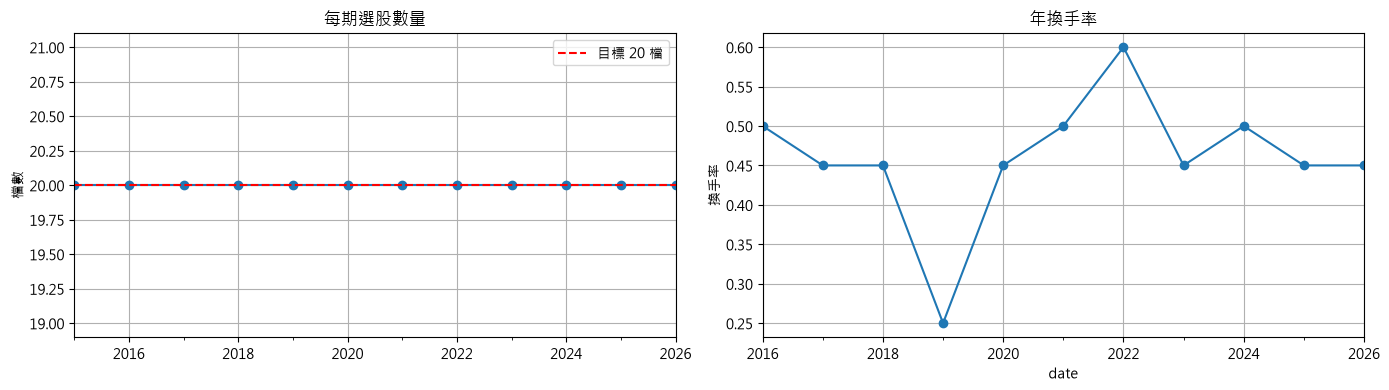

平均年換手率: 46%


In [13]:
# ── 7-A  覆蓋率 & 換手率 ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
counts.plot(ax=axes[0], marker='o', title='每期選股數量', ylabel='檔數', grid=True)
axes[0].axhline(N_STOCKS, color='r', ls='--', label=f'目標 {N_STOCKS} 檔'); axes[0].legend()
prev, tv = set(), []
for d in sorted(stock_list_by_date):
    cur = set(stock_list_by_date[d])
    if prev: tv.append({'date': d, 'turnover': len(prev - cur)/len(prev)})
    prev = cur
tv_df = pd.DataFrame(tv).set_index('date')
tv_df['turnover'].plot(ax=axes[1], marker='o', title='年換手率', ylabel='換手率', grid=True)
plt.tight_layout(); plt.show()
print(f'平均年換手率: {tv_df["turnover"].mean():.0%}')

In [14]:
# ── 7-B  訊號強度：iB/M vs 純 B/M 分位多空（無摩擦，n_q=5）──────
def monthly_returns(price_daily):
    '''由「日頻」還原報酬複利成月報酬 wide（index=Period[M], col=coid）。
    注意：須傳日頻 price_raw，不可傳已抽月底的 price_monthly（否則只取單日報酬）。'''
    d = price_daily.copy(); d['ym'] = d['mdate'].dt.to_period('M')
    d['gross'] = 1 + d['ROI'].fillna(0)/100.0
    return (d.groupby(['coid', 'ym'])['gross'].prod() - 1).unstack(0).sort_index()

def quantile_ls(fac_df, col, R, n_q=5):
    f = fac_df[['coid', 'avail_date', col]].rename(columns={col: 'score', 'avail_date': 'date'})
    f['ym'] = f['date'].dt.to_period('M')
    sp = f.sort_values('date').groupby(['coid', 'ym'])['score'].last().unstack(0)
    months = R.index; months = months[(months >= pd.Period('2015-01', 'M')) & (months <= pd.Period('2025-05', 'M'))]
    sp = sp.reindex(months).ffill(limit=14); cal, ics = {}, []
    for i, m in enumerate(months):
        s = sp.loc[m].dropna()
        if len(s) < n_q*10: continue
        if i+1 < len(months):
            ic = s.rank().corr(R.loc[months[i+1]].reindex(s.index).rank())
            if np.isfinite(ic): ics.append(ic)
        q = pd.qcut(s.rank(method='first'), n_q, labels=False); j = i+1
        if j >= len(months): break
        ls = R.loc[months[j]].reindex(s.index[q==n_q-1]).mean() - R.loc[months[j]].reindex(s.index[q==0]).mean()
        if np.isfinite(ls): cal[months[j]] = ls
    ls = pd.Series(cal).sort_index()
    return dict(年化=round(ls.mean()*12*100, 2), t=round(ls.mean()/(ls.std(ddof=1)/np.sqrt(len(ls))), 2),
                Sharpe=round(ls.mean()/ls.std(ddof=1)*np.sqrt(12), 2), IC=round(np.mean(ics), 4))
R = monthly_returns(price_raw)   # 用日頻 price_raw 複利成月報酬（非 price_monthly）
res = pd.DataFrame([{'因子': '純 B/M', **quantile_ls(fac, 'bm', R)},
                    {'因子': 'iB/M(無形調整)', **quantile_ls(fac, 'ibm', R)}])
print('無摩擦分位多空（2015–2024）：'); res

無摩擦分位多空（2015–2024）：


,因子,年化,t,Sharpe,IC
0,純 B/M,11.69,3.65,1.14,0.0382
1,iB/M(無形調整),13.42,4.56,1.42,0.0255


---
## 8｜Zipline 回測（TQuant Lab）

In [15]:
# ── 8-A  匯入股價資料（+ 基準 IR0001）─────────────────────────
from zipline.data.run_ingest import simple_ingest
all_selected = sorted(set(t for picks in stock_list_by_date.values() for t in picks))
ingest_pool = all_selected + ['IR0001']
simple_ingest(name='tquant', tickers=ingest_pool,
              start_date=START_DATE.replace('-', ''), end_date=END_DATE.replace('-', ''))

# ⚠ simple_ingest() 沒有回傳值、失敗也不拋錯——它內部只是
#   os.system('zipline ingest -b tquant')，走 shell 的 PATH。
#   兩個實測踩過的靜默失敗：
#     (1) name 只認 'tquant' / 'fundamentals'，傳其他名稱兩個分支都不成立，
#         函式什麼都不做也不報錯。
#     (2) 用絕對路徑呼叫 python.exe 而沒有 activate 環境時，Scripts 目錄不在
#         PATH 上 → 'zipline' 不是內部或外部命令 → ingest 沒跑。
#   兩種情況回測都會安靜地拿上一次 ingest 的舊 bundle 去跑，數字看起來正常但
#   對不上選股清單。所以這裡自己驗一次：逐一比對代號，缺任何一檔就中止。
#   （注意只比數量會漏——舊 bundle 可能比要求的檔數還多。）
from zipline.data import bundles as _bundles
_b = _bundles.load('tquant')
_sess = _b.equity_daily_bar_reader.sessions
_have = {a.symbol for a in _b.asset_finder.retrieve_all(_b.asset_finder.sids)}
_missing = sorted(set(ingest_pool) - _have)
print(f'ingest 完成：要求 {len(ingest_pool)} 檔、bundle 內 {len(_have)} 檔'
      f'｜交易日 {len(_sess)}（{str(_sess[0])[:10]} ~ {str(_sess[-1])[:10]}）')
if _missing:
    raise RuntimeError(
        f'ingest 後有 {len(_missing)} 檔不在 bundle 內，代表 ingest 未生效或不完整：'
        f'{_missing[:20]}{" ..." if len(_missing) > 20 else ""}'
    )


Now ingesting data.
End of ingesting tquant.
Please call function `get_bundle(start_dt = pd.Timestamp('20150601', tz = 'utc'),end_dt = pd.Timestamp('20260531' ,tz = 'utc'))` in `zipline.data.data_portal` to check data.
Currently used TEJ API key call quota 325/100000 (0.33%)
Currently used TEJ API key data quota 35490109/10000000 (354.9%)
ingest 完成：要求 80 檔、bundle 內 80 檔｜交易日 5326（2005-01-03 ~ 2026-09-01）


In [16]:
# ── 8-B  換股日與權重（年度 6 月；等權 或 反波動率）──────────
VOL = R.rolling(VOL_LOOKBACK, min_periods=6).std()          # 尾隨月報酬波動（反波動率加權用）
def make_weights(picks, sig_year):
    picks = [str(t) for t in picks]
    if not picks:
        return {}
    if WEIGHTING == 'equal':
        return {t: 1.0/len(picks) for t in picks}
    may_p = pd.Period(f'{sig_year}-05', 'M')                 # 訊號日（5 月底）尾隨波動
    v = VOL.loc[may_p].reindex(picks) if may_p in VOL.index else pd.Series(np.nan, index=picks)
    iv = (1.0/v).replace([np.inf, -np.inf], np.nan)
    iv = iv.fillna(iv.median())                              # 缺波動者給中位數
    w = iv/iv.sum()
    return w.to_dict()

rebal_map, weight_map = {}, {}
for sig, picks in stock_list_by_date.items():
    rebal_date = pd.Timestamp(sig.year, REBAL_MONTH, 1)     # 訊號年的 6 月換倉
    rebal_map[rebal_date] = [str(t) for t in picks]
    weight_map[rebal_date] = make_weights(picks, sig.year)
print(f'年度換股次數: {len(rebal_map)} | 加權={WEIGHTING} | 首次: {min(rebal_map).date()}')

年度換股次數: 12 | 加權=invvol | 首次: 2015-06-01


In [17]:
# ── 8-C  Zipline 策略（依 weight_map 加權、年度再平衡）─────────
from zipline.api import (order_target_percent, set_commission, set_slippage,
    record, schedule_function, date_rules, time_rules, symbol, set_benchmark,
    cancel_order, get_open_orders)
from zipline.finance import slippage
from zipline.finance.commission import Custom_TW_Commission

def initialize(context):
    set_commission(Custom_TW_Commission(tax=0.003, discount=0.35, min_trade_cost=20.0))  # 台股手續費折0.35+證交稅0.3%
    set_slippage(slippage.NoSlippage())
    set_benchmark(symbol('IR0001'))                        # 含息報酬指數
    context.target_weights = {}
    schedule_function(rebalance, date_rules.month_start(), time_rules.market_open())

def _can_load(t):
    try: symbol(t); return True
    except Exception: return False

def before_trading_start(context, data):
    ym = (data.current_dt.year, data.current_dt.month)
    context.target_weights = {}
    for rebal_date, picks in rebal_map.items():
        if (rebal_date.year, rebal_date.month) == ym:
            wts = weight_map.get(rebal_date, {})
            for t in picks:
                if _can_load(t) and t in wts:
                    context.target_weights[symbol(t)] = wts[t]
            break

def rebalance(context, data):
    target = context.target_weights
    if not target:
        return
    for asset, orders in get_open_orders().items():
        for o in orders: cancel_order(o)
    for pos in context.portfolio.positions:                # 清倉不在名單者
        if pos not in target:
            order_target_percent(pos, 0)
    for asset, w in target.items():                         # 依權重買進名單
        if data.can_trade(asset):
            order_target_percent(asset, w)
    # 註：本函式內不 record 持倉數。order_target_percent 只是掛單、當日收盤才成交，
    #     此刻的 context.portfolio.positions 仍是「下單前」的舊部位；且本函式只在調倉月執行，
    #     record 出來的序列會變成「首年 0 檔、次年起才 20 檔」的假象。
    #     每日真實持倉一律用 Zipline 內建的 perf['longs_count']（見 9-A 平均持倉數）。
    log.info(f'{data.current_dt.date()} 年度調倉 {len(target)} 檔')

def analyze(context, perf):
    fig, ax = plt.subplots(figsize=(14, 5.5))
    cum = (1+perf['returns']).cumprod()-1; bm = (1+perf['benchmark_return']).cumprod()-1
    cum.plot(ax=ax, label='iValue_TW（iB/M v2 反波動率 N=20）', lw=2, color='#2E86AB')
    bm.plot(ax=ax, label='IR0001 含息報酬指數', lw=1.5, alpha=.7, color='#A23B72')
    ax.set_title(f"累積報酬 vs 含息基準（{perf.index[0]:%Y-%m-%d} ~ {perf.index[-1]:%Y-%m-%d}）",
                 fontweight='bold')
    ax.set_ylabel('累積報酬率'); ax.set_xlabel('')
    ax.legend(); ax.grid(True, alpha=.3); ax.axhline(0, color='k', lw=.8, ls='--', alpha=.5)
    plt.tight_layout(); plt.show()
print('策略函數定義完成（依 weight_map 加權、年度再平衡）')

策略函數定義完成（依 weight_map 加權、年度再平衡）


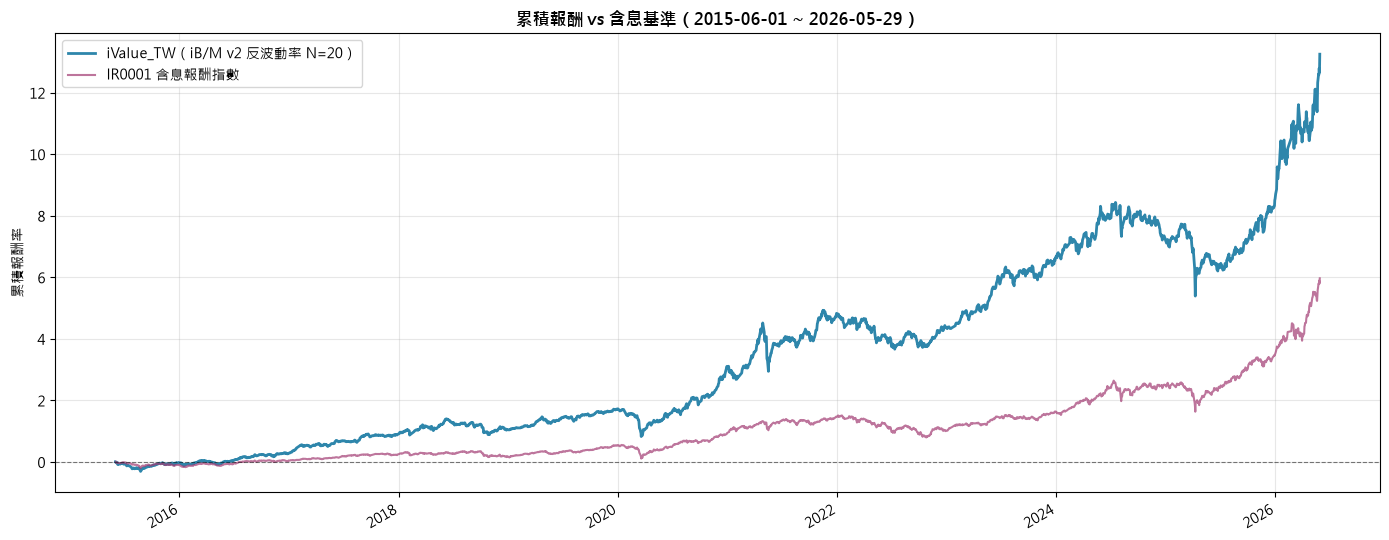

回測完成


In [18]:
# ── 8-D  執行回測 ─────────────────────────────────────────────
from zipline import run_algorithm
results = run_algorithm(
    start=pd.Timestamp(START_DATE, tz='utc'), end=pd.Timestamp(END_DATE, tz='utc'),
    initialize=initialize, before_trading_start=before_trading_start, analyze=analyze,
    bundle='tquant', capital_base=CAPITAL_BASE)
print('回測完成')

---
## 9｜績效摘要

In [19]:
total_ret  = (results['portfolio_value'].iloc[-1]/CAPITAL_BASE - 1)*100
bm_ret     = results['benchmark_period_return'].iloc[-1]*100
r = results['returns']; yrs = (results.index[-1]-results.index[0]).days/365.25
cagr = (results['portfolio_value'].iloc[-1]/CAPITAL_BASE)**(1/yrs)-1
max_dd = results['max_drawdown'].min()*100
sharpe = results['sharpe'].iloc[-1]
avg_pos = results['longs_count'].mean()   # 每日實際持倉（非 record 的 num_positions）
print('='*44)
print(f'  策略總報酬   : {total_ret:>8.2f}%')
print(f'  年化報酬CAGR : {cagr*100:>8.2f}%')
print(f'  基準總報酬   : {bm_ret:>8.2f}%')
print(f'  超額(總)     : {total_ret-bm_ret:>8.2f}%')
print(f'  最大回撤     : {max_dd:>8.2f}%')
print(f'  夏普比率     : {sharpe:>8.2f}')
print(f'  平均持倉數   : {avg_pos:>8.1f} 檔')
print('='*44)
results.to_csv('iValue_TW_results.csv'); print('詳細結果已存 iValue_TW_results.csv')

  策略總報酬   :  1324.47%
  年化報酬CAGR :    27.34%
  基準總報酬   :   596.20%
  超額(總)     :   728.28%
  最大回撤     :   -33.06%
  夏普比率     :     1.31
  平均持倉數   :     20.0 檔
詳細結果已存 iValue_TW_results.csv


Start date,2015-06-01
End date,2026-05-29
Total months,127
,Backtest
Annual return,28.35%
Cumulative returns,1324.473%
Annual volatility,20.664%
Sharpe ratio,1.31
Calmar ratio,0.86
Stability,0.97
Max drawdown,-33.056%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,33.06,2020-01-02,2020-03-19,2020-07-06,120
1,32.26,2024-07-17,2025-04-09,2025-12-30,355
2,31.03,2015-06-01,2015-08-24,2016-03-02,185
3,28.51,2021-04-28,2021-05-17,2021-10-28,127
4,21.35,2021-11-15,2022-07-12,2023-04-11,338


Top 10 long positions of all time,max
sid,
2908,22.59%
2345,17.99%
2915,16.79%
2337,16.55%
2388,16.35%
2841,15.89%
3481,14.53%
5512,14.51%
3704,14.42%


Top 10 short positions of all time,max
sid,


Top 10 positions of all time,max
sid,
2908,22.59%
2345,17.99%
2915,16.79%
2337,16.55%
2388,16.35%
2841,15.89%
3481,14.53%
5512,14.51%
3704,14.42%


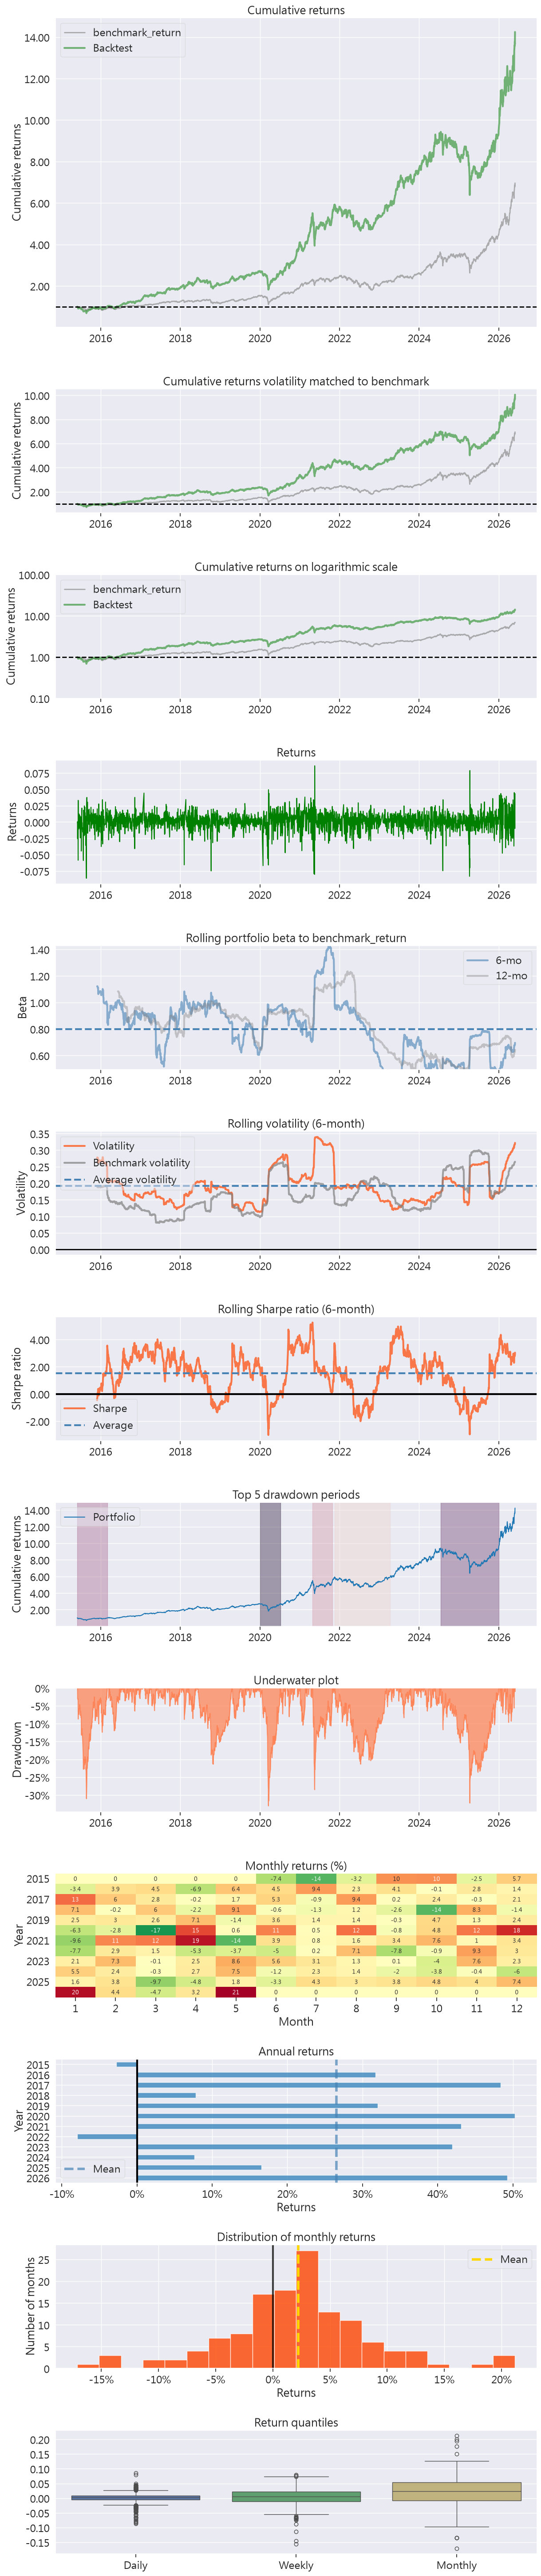

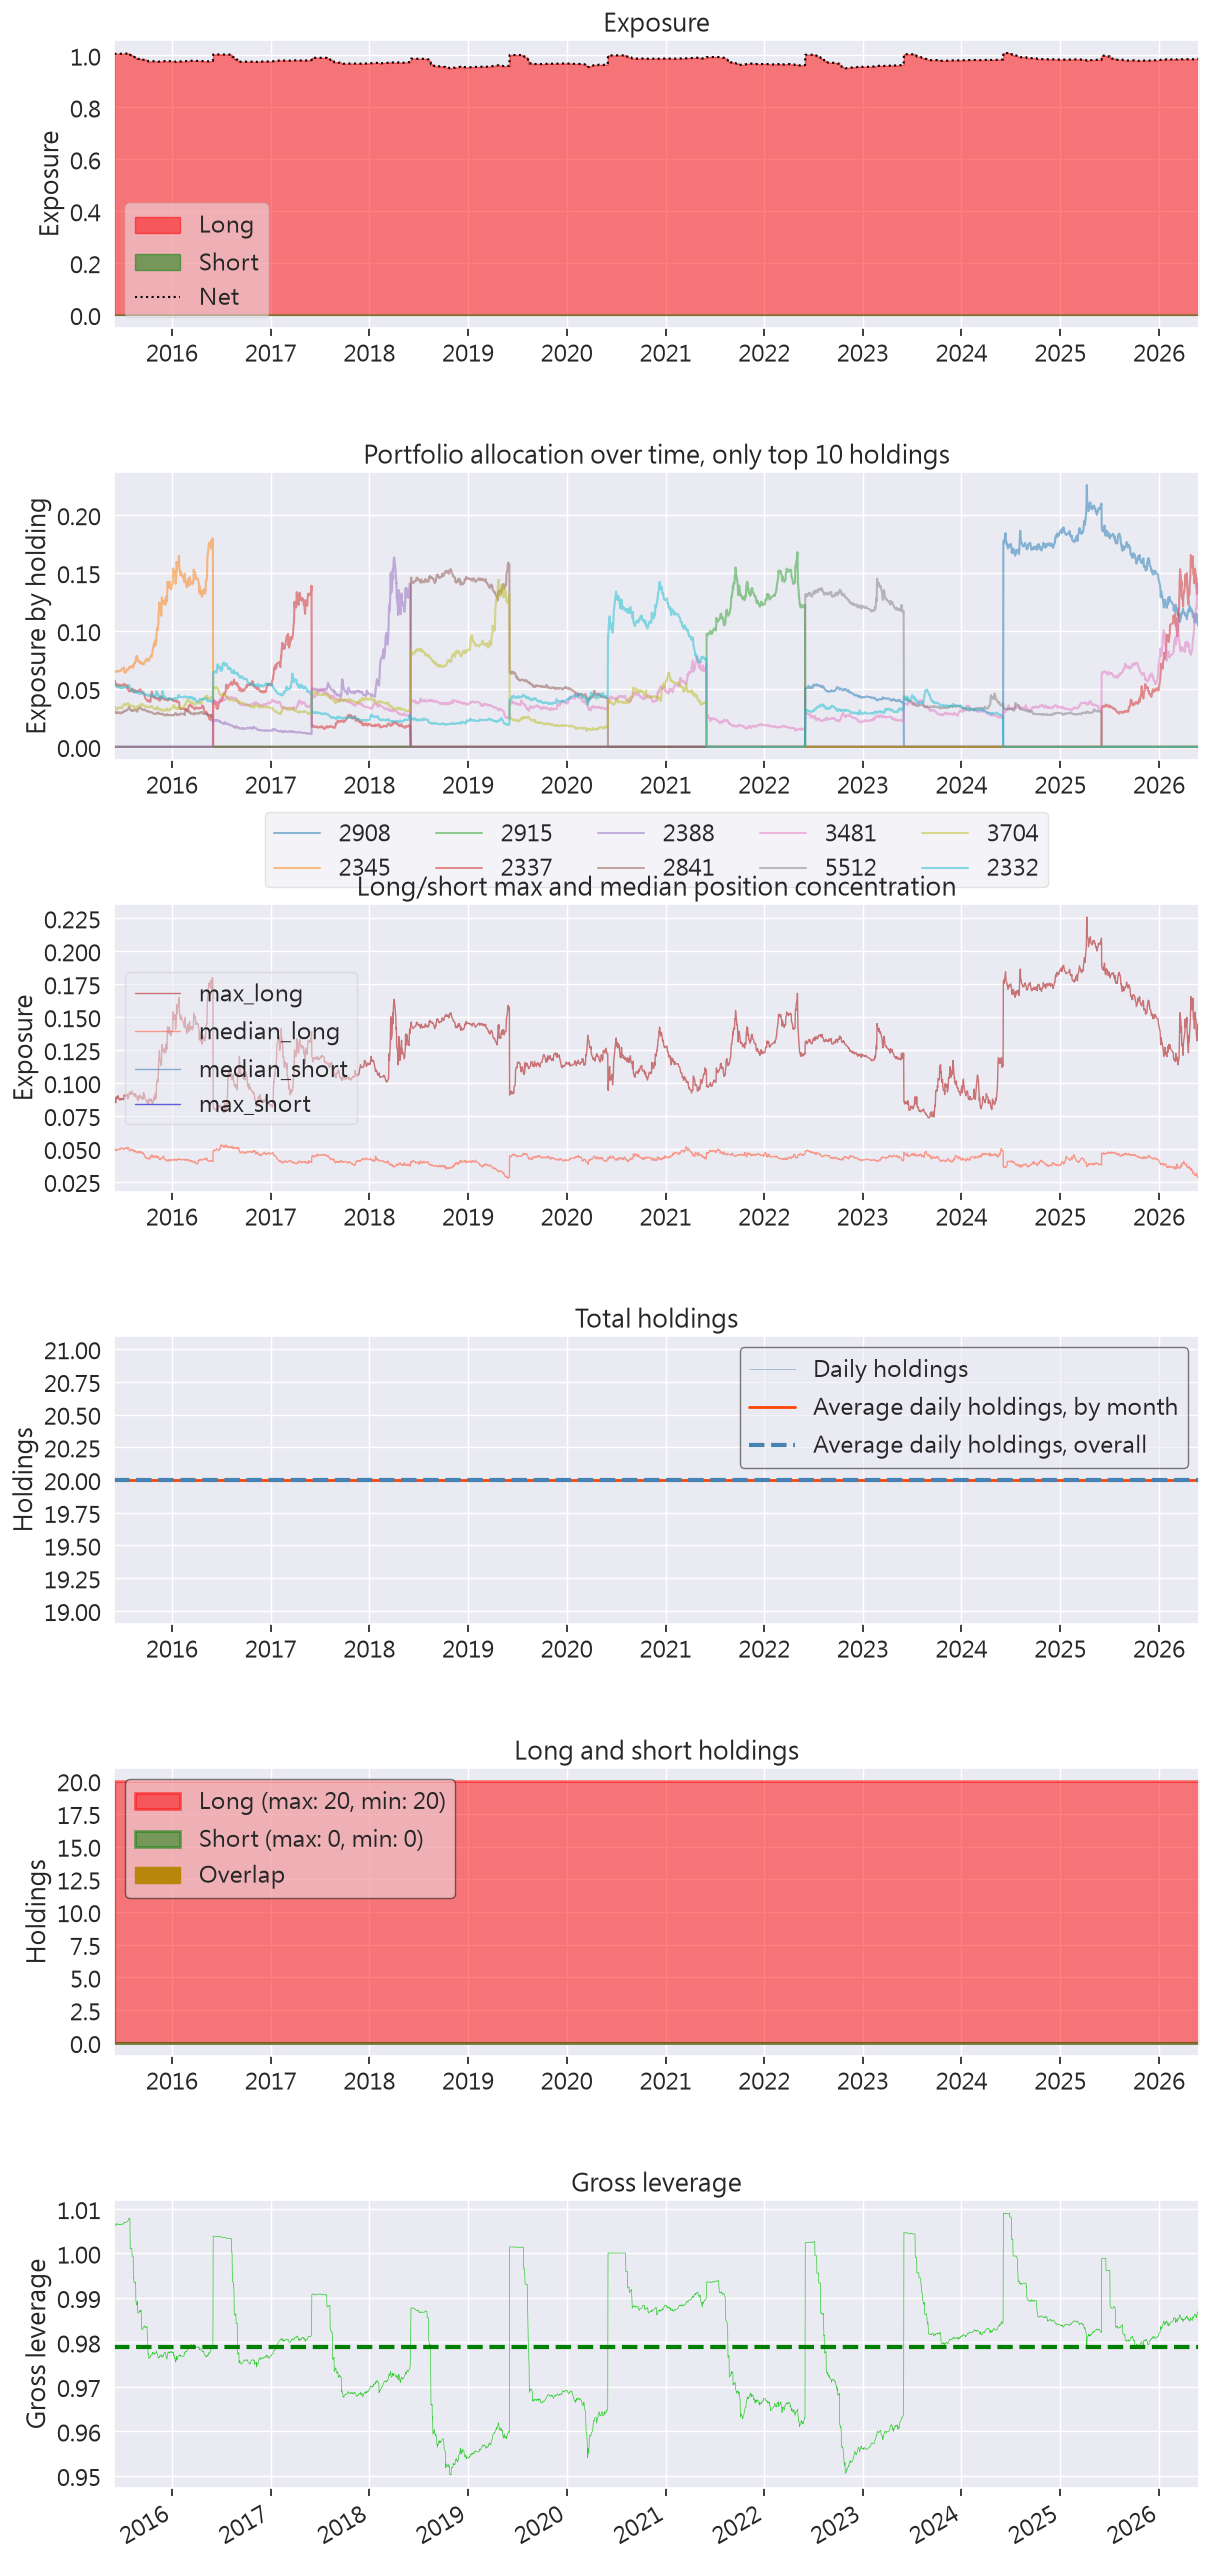

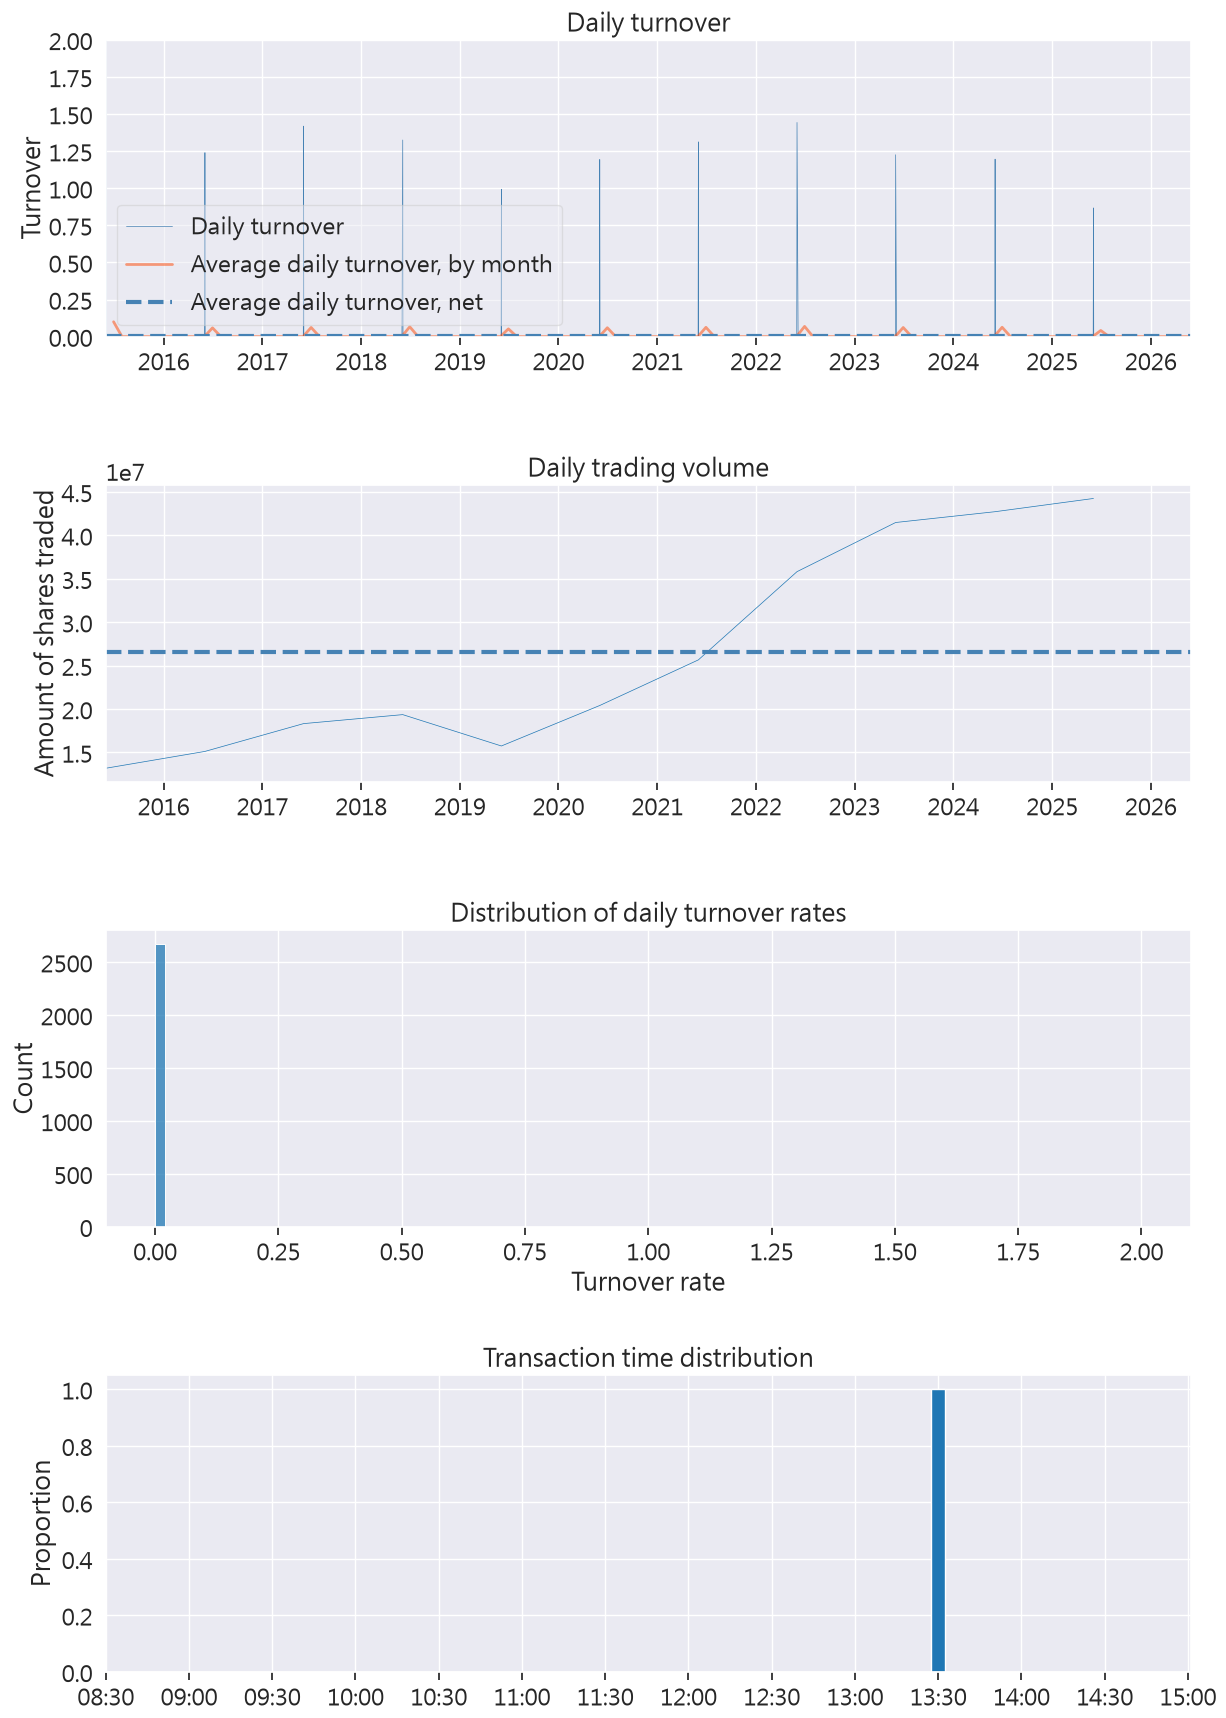

In [20]:
# ── Pyfolio 完整分析（選用）──────────────────────────────────
try:
    import pyfolio as pf
    from pyfolio.utils import extract_rets_pos_txn_from_zipline
    returns, positions, transactions = extract_rets_pos_txn_from_zipline(results)
    pf.tears.create_full_tear_sheet(returns=returns, positions=positions,
        transactions=transactions, benchmark_rets=results.benchmark_return)
except ImportError:
    print('未安裝 pyfolio，略過完整分析')